### Tesla Stock Price Prediction for 8 years using three models in sklearn.

##### 1. Importing Libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Loading Dataset

In [83]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/22-Tesla%20Stock%20Price%20%20Prediction/Tesla.csv

--2026-03-13 09:06:02--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/22-Tesla%20Stock%20Price%20%20Prediction/Tesla.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109953 (107K) [text/plain]
Saving to: ‘Tesla.csv.2’

Tesla.csv.2         100%[===================>] 107.38K  --.-KB/s    in 0.06s   

2026-03-13 09:06:02 (1.85 MB/s) - ‘Tesla.csv.2’ saved [109953/109953]



In [84]:
df = pd.read_csv('Tesla.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


##### 3. Preprocessing

1. Exploratory Data Analysis

In [85]:
df.shape

(1692, 7)

In [86]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


In [88]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


In [89]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


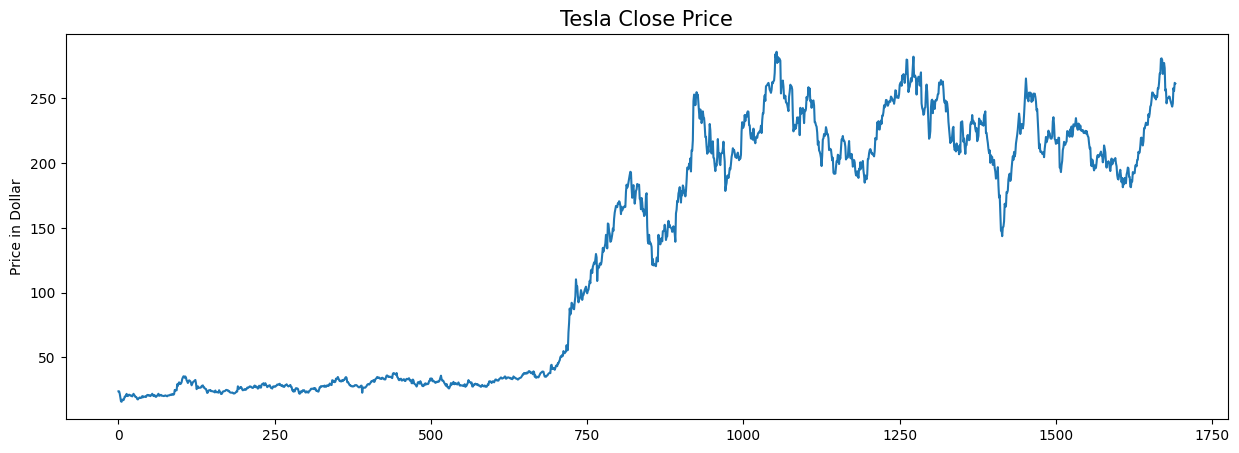

In [90]:
plt.figure(figsize=(15, 5))
plt.plot(df['Close'])
plt.title('Tesla Close Price', fontsize= 15)
plt.ylabel("Price in Dollar")
plt.show()

In [91]:
df[df['Close']== df['Adj Close']].shape

(1692, 7)

In [92]:
df = df.drop('Adj Close', axis = 1)

In [93]:
df.head()

,Date,Open,High,Low,Close,Volume
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900


/tmp/ipykernel_296/1915636619.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_296/1915636619.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_296/1915636619.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seab

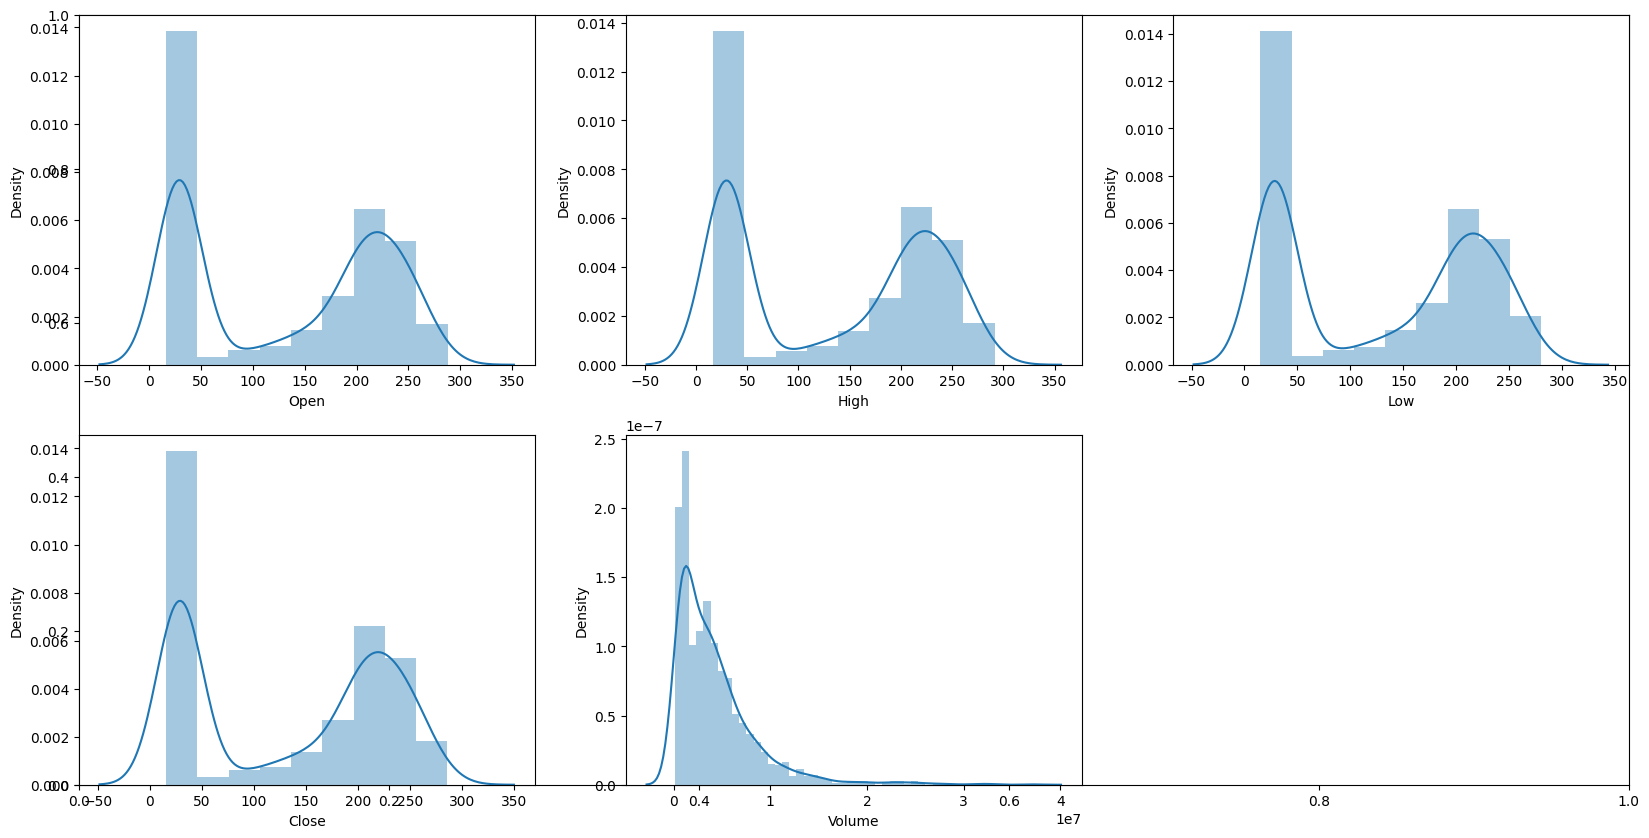

In [94]:
plt.subplots(figsize=(20, 10))
for i, col in enumerate(df.columns[1:]):
    plt.subplot(2, 3, i+1)
    sns.distplot(df[col])
plt.show()

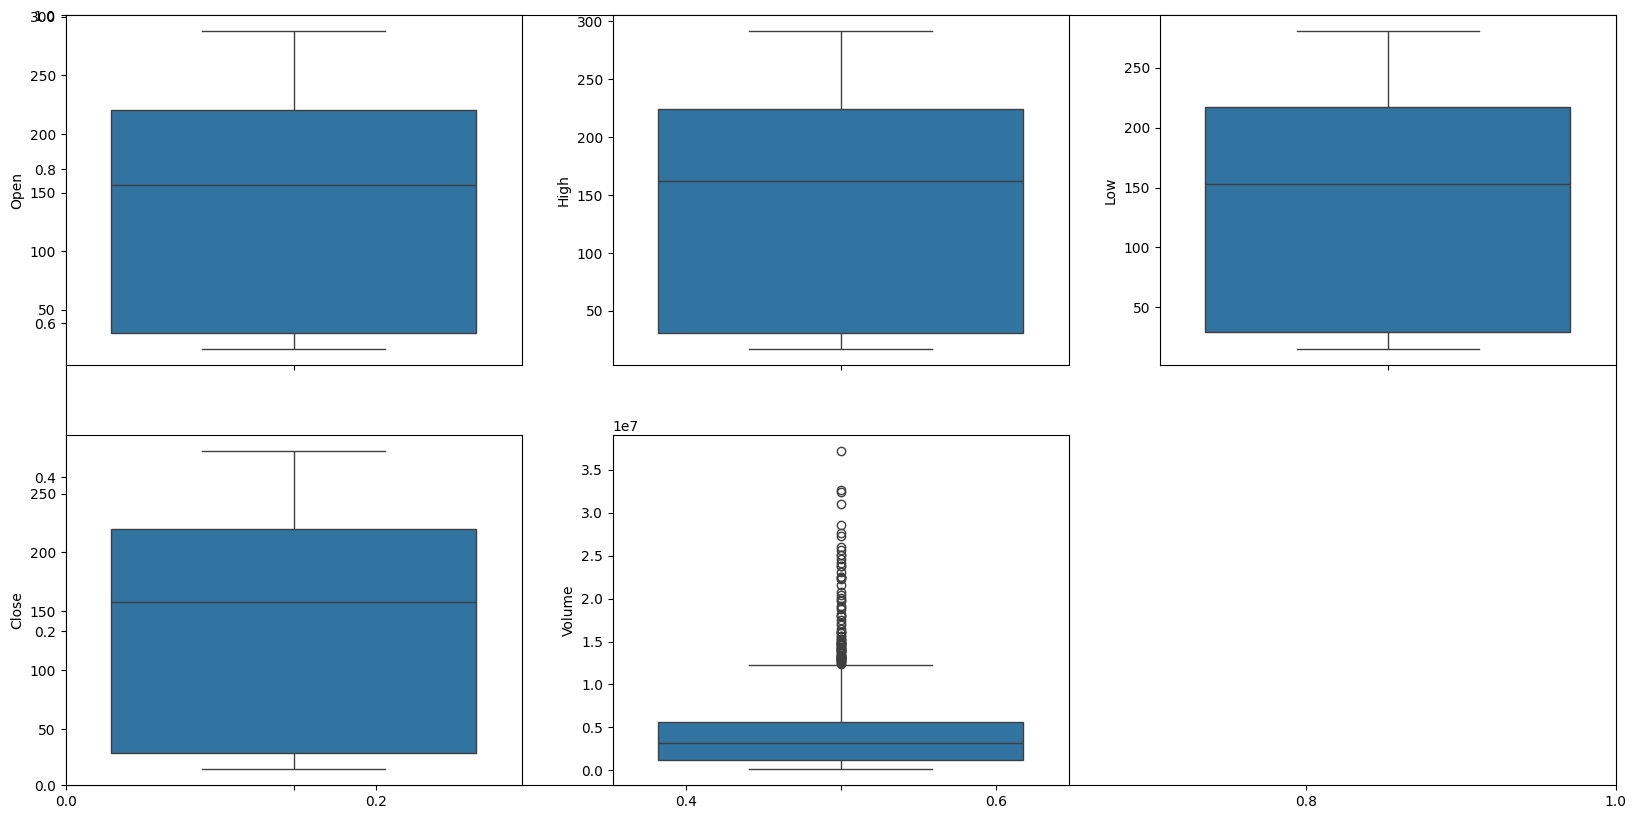

In [95]:
plt.subplots(figsize= (20, 10))
for index, col in enumerate(df.columns[1:]):
    plt.subplot(2, 3, index +1)
    sns.boxplot(df[col])
plt.show()

2. Feature Engineering

In [96]:
df.head()

,Date,Open,High,Low,Close,Volume
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900


In [97]:
splited = df['Date'].str.split('/', expand=True)
df['Day'] = splited[1].astype(int)
df['Month'] = splited[0].astype(int)
df['Year'] = splited[2].astype(int)
df.head()

,Date,Open,High,Low,Close,Volume,Day,Month,Year
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1692 non-null   object 
 1   Open    1692 non-null   float64
 2   High    1692 non-null   float64
 3   Low     1692 non-null   float64
 4   Close   1692 non-null   float64
 5   Volume  1692 non-null   int64  
 6   Day     1692 non-null   int64  
 7   Month   1692 non-null   int64  
 8   Year    1692 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 119.1+ KB


In [99]:
df['is_quarter_end'] = np.where(df['Month']%3 == 0,1,0)
df.head()

,Date,Open,High,Low,Close,Volume,Day,Month,Year,is_quarter_end
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0


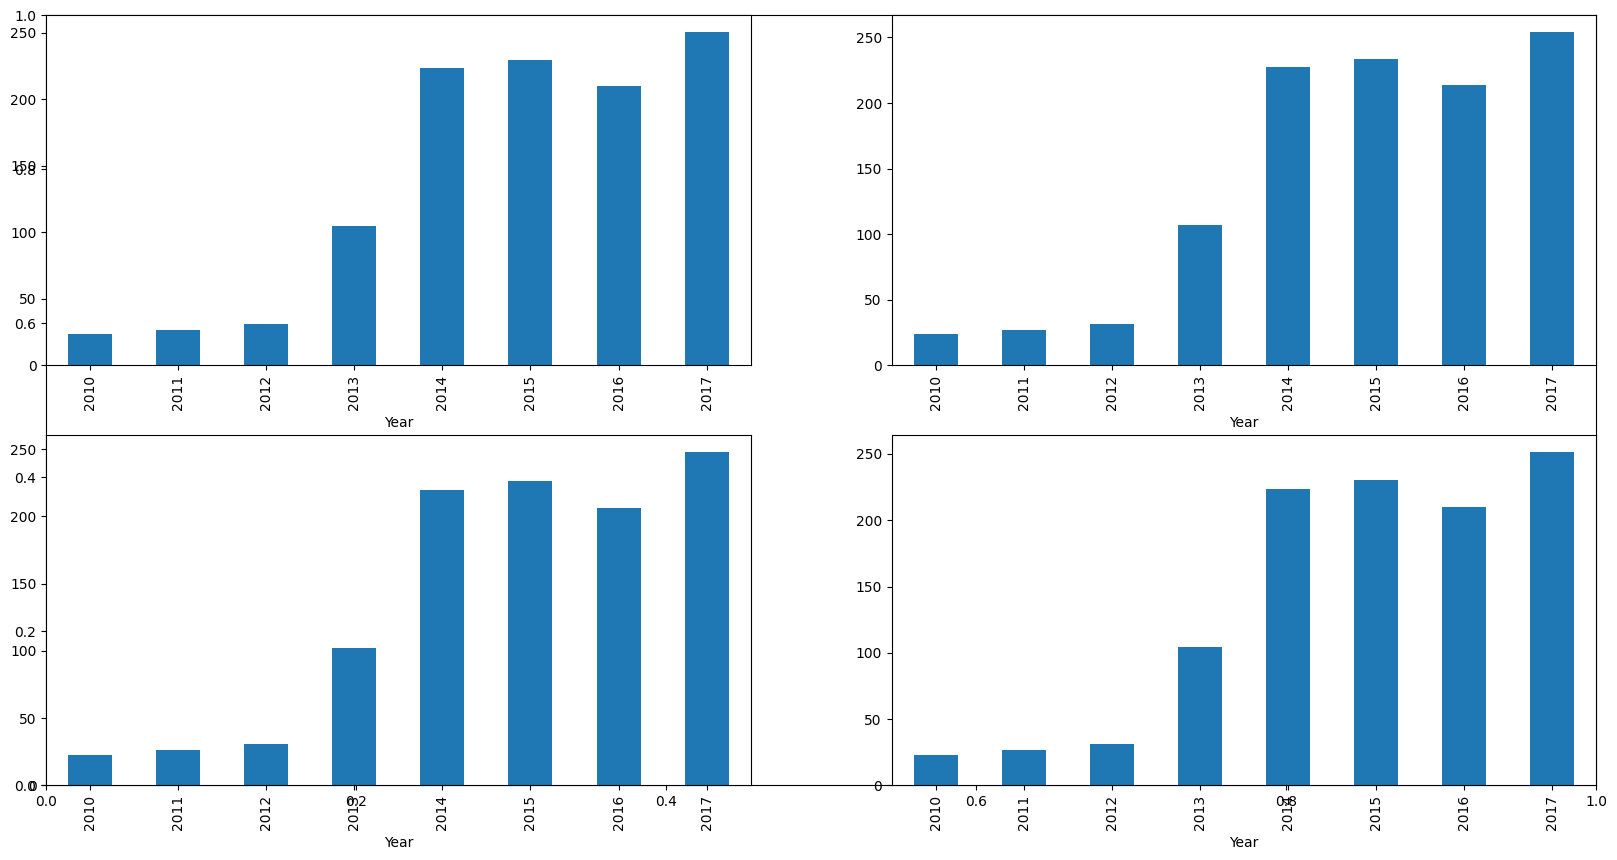

In [100]:
data_grouped = df.drop('Date', axis=1).groupby('Year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

# This code is modified by Susobhan Akhuli

In [101]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean()

,Open,High,Low,Close,Volume,Day,Month,Year
is_quarter_end,,,,,,,,
0,130.813739,133.182620,128.257229,130.797709,4.461581e+06,15.686501,6.141208,2013.353464
1,135.679982,137.927032,133.455777,135.673269,3.891084e+06,15.657244,7.584806,2013.314488


In [102]:
df['close-open'] = df['Close'] - df['Open']
df['low-high'] = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

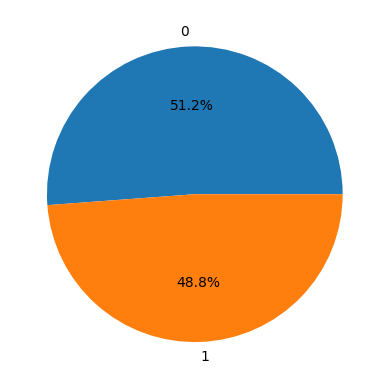

In [103]:
plt.pie(
    df['target'].value_counts().values,
    labels=[0,1],
    autopct='%1.1f%%'
)
plt.show()

In [104]:
df.head()

,Date,Open,High,Low,Close,Volume,Day,Month,Year,is_quarter_end,close-open,low-high,target
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1,4.889999,-7.459999,0
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1,-1.960001,-7.120001,0
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0,-3.040001,-5.650000,0
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0,-3.799999,-4.390001,0
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0,-3.889999,-4.170000,0


In [105]:
df.drop('Date', axis= 1, inplace= True)

In [106]:
df.head()

,Open,High,Low,Close,Volume,Day,Month,Year,is_quarter_end,close-open,low-high,target
0,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1,4.889999,-7.459999,0
1,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1,-1.960001,-7.120001,0
2,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0,-3.040001,-5.650000,0
3,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0,-3.799999,-4.390001,0
4,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0,-3.889999,-4.170000,0


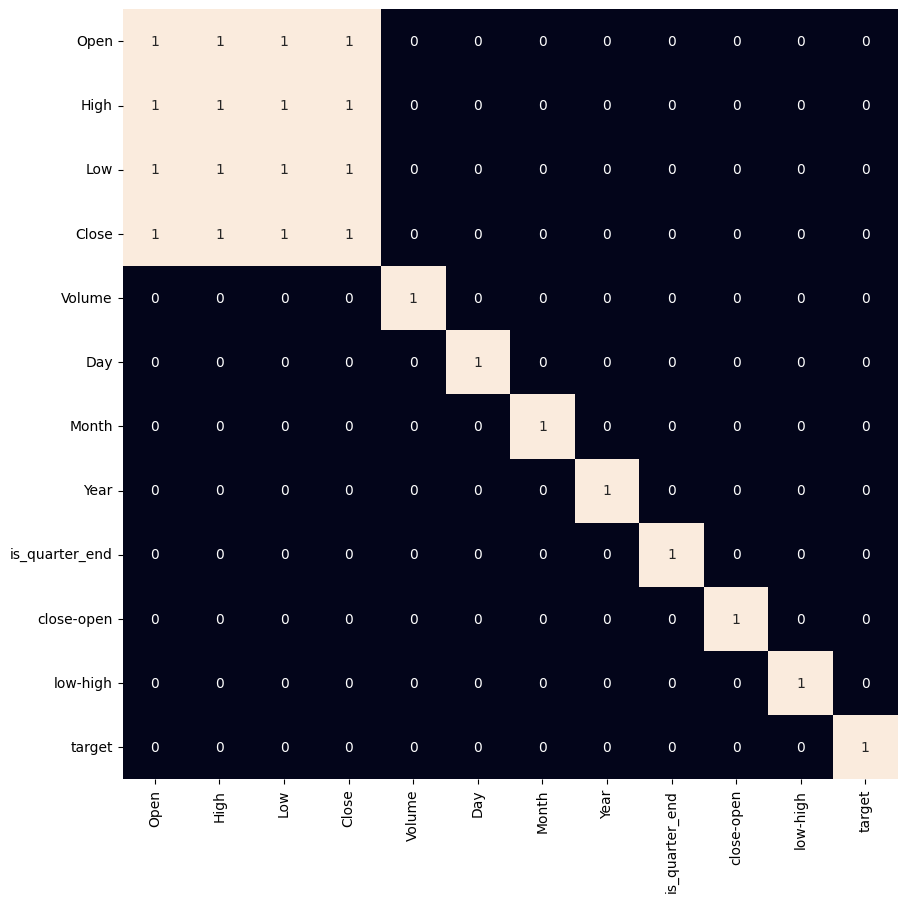

In [107]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr()> 0.9, annot=True, cbar=False)
plt.show()

In [108]:
df.drop(columns=['Open', 'High', 'Close', 'Low'], axis = 1, inplace=True)

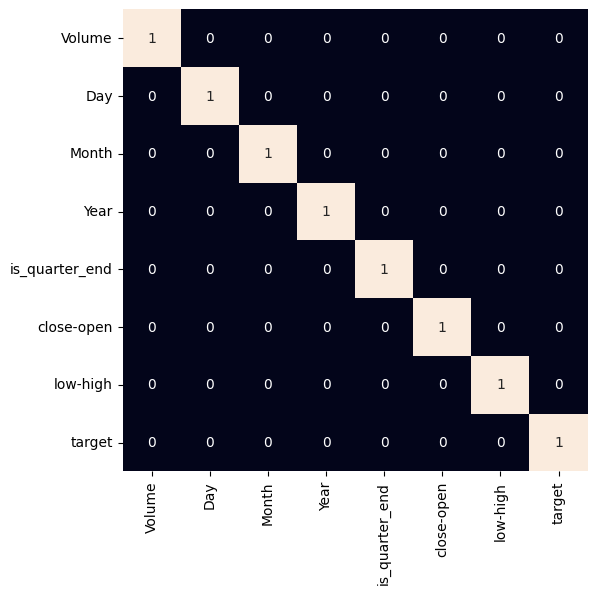

In [109]:
plt.figure(figsize=(6, 6))
sns.heatmap(df.corr()> 0.9, annot=True, cbar=False)
plt.show()

In [110]:
df.head()

,Volume,Day,Month,Year,is_quarter_end,close-open,low-high,target
0,18766300,29,6,2010,1,4.889999,-7.459999,0
1,17187100,30,6,2010,1,-1.960001,-7.120001,0
2,8218800,1,7,2010,0,-3.040001,-5.650000,0
3,5139800,2,7,2010,0,-3.799999,-4.390001,0
4,6866900,6,7,2010,0,-3.889999,-4.170000,0


In [111]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

3. Train Test Split

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

4. Feature Scalling

In [113]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [114]:
X_train

array([[-0.20852915,  1.19843887,  0.12482181, ..., -0.70571347,
         0.49255879,  0.03065592],
       [ 1.61938682, -0.41584367,  0.12482181, ..., -0.70571347,
         1.19451945, -0.14815515],
       [-0.85936332,  1.42905066, -1.31659541, ..., -0.70571347,
         0.04363308,  0.87081857],
       ...,
       [ 2.2064033 ,  1.19843887,  1.27795558, ..., -0.70571347,
         0.30210714, -0.43964123],
       [-0.13406363, -0.06992598, -0.74002853, ..., -0.70571347,
         0.86802706, -0.16040513],
       [ 0.70099416,  0.16068581,  1.56623903, ...,  1.41700569,
         3.46909287, -2.24733951]])

##### 4. Build and Fit The Models

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

models = [
    LogisticRegression(),
    SVC(kernel='poly', probability=True),
    XGBClassifier()
]

training_accuracy = []
validation_accuracy = []

for i in range(len(models)):
    models[i].fit(X_train, y_train)

    print(f"{models[i]} : ")
    train_acu = roc_auc_score(y_train, models[i].predict_proba(X_train)[:,1])
    training_accuracy.append(train_acu)
    print(f"Training Accuracy: {train_acu}")

    val_acu = roc_auc_score(y_test, models[i].predict_proba(X_test)[:,1])
    validation_accuracy.append(val_acu)
    print(f"Validation Accuracy: {val_acu}")


LogisticRegression() : 
Training Accuracy: 0.5404161477791614
Validation Accuracy: 0.454954954954955
SVC(kernel='poly', probability=True) : 
Training Accuracy: 0.39012038190120385
Validation Accuracy: 0.5197072072072072
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accurac

##### 5. Evaluating Models

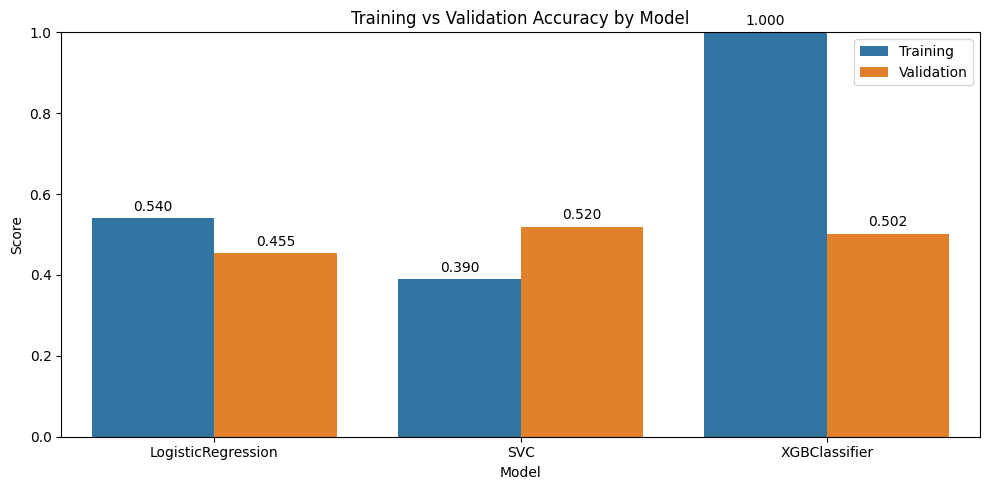

In [123]:
model_names = [type(m).__name__ for m in models]

plot_df = pd.DataFrame({
    "Model": model_names,
    "Training": training_accuracy,
    "Validation": validation_accuracy
})

plot_df = plot_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.set_title("Training vs Validation Accuracy by Model")
ax.set_ylim(0, 1)
plt.legend(title="")
plt.tight_layout()
plt.show()

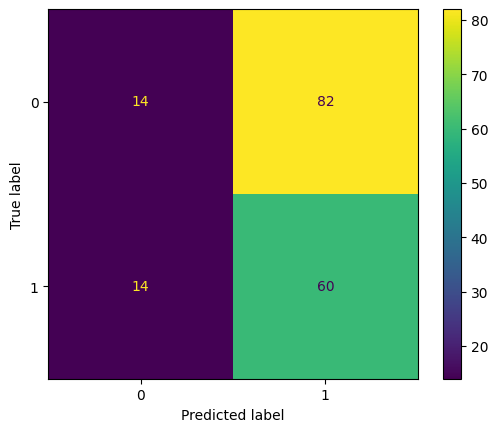

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = models[0].predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=models[0].classes_)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[0].classes_)
display.plot()
plt.show()

##### 6. Make Prediction

In [117]:
print(f'Actual: {y_test[0]}  Prediction: {y_pred[0]}')

Actual: 1  Prediction: 1


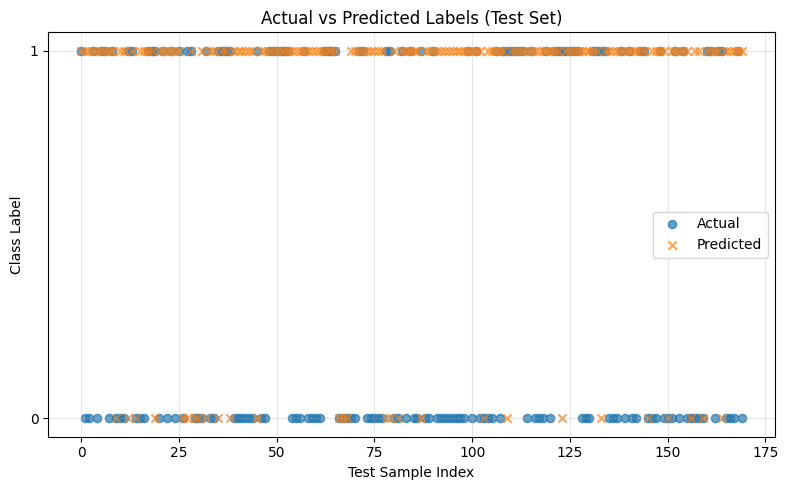

In [126]:
plt.figure(figsize=(8, 5))
idx = np.arange(len(y_test))

plt.scatter(idx, y_test, label='Actual', alpha=0.7, s=35)
plt.scatter(idx, y_pred, label='Predicted', alpha=0.7, s=35, marker='x')

plt.title('Actual vs Predicted Labels (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Class Label')
plt.yticks([0, 1])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()